<a href="https://www.kaggle.com/code/meylisaputri/hology-cattle-and-foot-disease-in-cow?scriptVersionId=347983607" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Published on April 07, 2026. By Prata, Marília (mpwolke)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Two lines Required to Plot Plotly
import plotly.io as pio
pio.renderers.default = 'iframe'

import plotly.graph_objs as go
import plotly.offline as py
import plotly.express as px

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased muzzle 38 with tongue.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased udder 38.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased udder 14.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased udder 9.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased muzzle 15 with tongue.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased udder 53.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased udder 22.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Non-diseased udder 51.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Cows head, open mouth 7.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Dorsal side of tongue 3.jpg
/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle/0/Dorsal side of tongue 5.jpg
/kaggle/input/datasets/

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D,
    Rescaling, Input
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


2026-09-07 13:51:32.491153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788789092.708328      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788789092.779535      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788789093.283530      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788789093.283576      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788789093.283579      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Cattle Foot and Mouth Disease (FMD)

"Foot and mouth disease (FMD) in cattle is a highly contagious, severe viral disease caused by an aphthovirus, affecting cloven-hoofed animals and causing significant economic losses. Key symptoms include high fever (approx. 40°C), severe salivation, and blisters (vesicles) on the tongue, gums, lips, teats, and between the hooves, leading to lameness, reduced milk yield, and potential mortality in calves."

"FMD is one of the world's most economically important viral diseases of livestock. The virus infects cattle, pigs, sheep, goats, and many cloven-hoofed wildlife species. The infection results in vesicular lesions in and around the mouth and on the feet, and animals become reluctant to eat or move. Confirmation of the infection requires laboratory analysis, usually involving real-time RT-PCR assay, and serotyping is achieved using antigen ELISA or nucleotide sequencing. Inactivated virus vaccines are available."

https://www.msdvetmanual.com/infectious-diseases/foot-and-mouth-disease/foot-and-mouth-disease-in-animals

In [3]:
#By Bisma Ali https://www.kaggle.com/code/bismahali/karachi-transport-dataset-eda-ida

import cv2

# Dataset Path
dataset_path = "/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle" 

# Show folders/classes
classes = os.listdir(dataset_path)
print("Dataset Classes:", classes)

Dataset Classes: ['0', '1']


## Count images in Classes

Examples on zero and one classes.

Zero (0): Calf, underside of tongue;;; Cow mouth with teeth;;; Cows head, open mouth

One (1): 1 day vesicle, cow, teat;;; 10 day lesions, steer, tongue;;;2 day vesicle, steer, foot

In [4]:
#By Bisma Ali https://www.kaggle.com/code/bismahali/karachi-transport-dataset-eda-ida

class_counts = {}

for cls in classes:
    cls_folder = os.path.join(dataset_path, cls)
    images = [img for img in os.listdir(cls_folder) if img.lower().endswith(('.jpg','.png','.jpeg'))]
    class_counts[cls] = len(images)

print("\nImages Count per Class:")
for cls, cnt in class_counts.items():
    print(f"{cls} : {cnt}")

total_images = sum(class_counts.values())
print("\nTotal Images in Dataset:", total_images)


Images Count per Class:
0 : 173
1 : 169

Total Images in Dataset: 342


### Samples by class

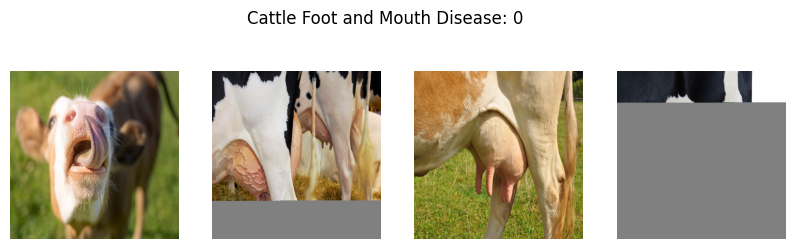

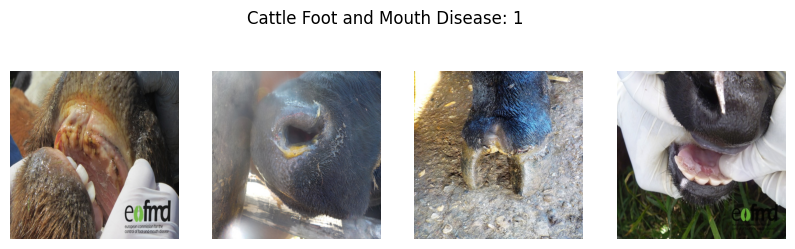

In [5]:
#By Bisma Ali https://www.kaggle.com/code/bismahali/karachi-transport-dataset-eda-ida

def show_samples(n=4):
    for cls in classes:
        folder = os.path.join(dataset_path, cls)
        imgs = os.listdir(folder)[:n]

        plt.figure(figsize=(10,3))
        plt.suptitle(f"Cattle Foot and Mouth Disease: {cls}")

        for i, img_name in enumerate(imgs):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.axis("off")

        plt.show()

show_samples(4)

In [6]:
# ============================================================
# DATASET CONFIGURATION
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle"

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 30          # phase 1: train the classification head only
FINE_TUNE_EPOCHS = 20  # phase 2: fine-tune top layers of the backbone

# Folder order must stay consistent with labels
CLASSES = ["0", "1"]

# Human-readable labels for reports and Raspberry Pi
LABEL_NAMES = {
    0: "Normal",
    1: "PMK"
}

print("Dataset path:", DATASET_PATH)
print("Classes:", CLASSES)
print("Label mapping:", LABEL_NAMES)


Dataset path: /kaggle/input/datasets/meylisaputri/fmd-cattle/FMD_Cattle
Classes: ['0', '1']
Label mapping: {0: 'Normal', 1: 'PMK'}


In [7]:
# ============================================================
# LOAD DATASET
# IMPORTANT: convert BGR -> RGB so Raspberry Pi preprocessing
# can use the same RGB format.
# ============================================================

X = []
y = []
skipped_files = []

for label, class_name in enumerate(CLASSES):
    folder_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Class folder not found: {folder_path}")

    for img_name in sorted(os.listdir(folder_path)):
        if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            skipped_files.append(img_path)
            continue

        # OpenCV reads BGR -> convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0

        X.append(img)
        y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Dataset loaded")
print("Images shape:", X.shape)
print("Labels shape:", y.shape)

for label, name in LABEL_NAMES.items():
    print(f"{name} ({label}): {np.sum(y == label)} images")

print("Skipped files:", len(skipped_files))
if skipped_files:
    print(skipped_files[:10])


Corrupt JPEG data: premature end of data segment


Dataset loaded
Images shape: (342, 128, 128, 3)
Labels shape: (342,)
Normal (0): 173 images
PMK (1): 169 images
Skipped files: 0


In [8]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

## Model Building — Convolutional Neural Network (CNN)

Dense 2= 2 classes

We don't have train/test/val

"We construct a CNN model with convolution, pooling, and dropout layers to prevent overfitting."

In [9]:
# ============================================================
# TRANSFER LEARNING MODEL (MobileNetV2 backbone)
# ------------------------------------------------------------
# The dataset only has 342 images. A CNN trained from scratch on
# that few samples cannot learn useful features and collapses to
# predicting the majority class (this is what caused the ~54%
# "coin flip" accuracy in the original version of this notebook).
#
# Instead we reuse an ImageNet-pretrained MobileNetV2 as a fixed
# feature extractor, train a small classifier head on top, and
# later fine-tune its last layers (see the training cell below).
# MobileNetV2 is also lightweight enough for the Raspberry Pi
# deployment target of this project.
# ============================================================

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze backbone for phase 1

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# X was normalized to [0, 1] while loading the dataset (see the
# LOAD DATASET cell) -> rescale back to [0, 255] then apply
# MobileNetV2's own preprocessing (which maps it to [-1, 1]).
x = Rescaling(255.0)(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(2, activation="softmax", name="prediction")(x)

model = keras.Model(inputs, outputs, name="fmd_mobilenetv2")

print("Model created successfully")
print("Trainable params (head only):",
      sum(int(tf.size(w)) for w in model.trainable_weights))


I0000 00:00:1788789124.000155      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788789124.006137      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model created successfully
Trainable params (head only): 164226


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## Model Summary

In [11]:
model.summary()

Model: "fmd_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## train test split

In [12]:
# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# 70% train, 15% validation, 15% test
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples      :", len(X_test))

# Class weights: the dataset is slightly imbalanced (173 vs 169),
# but computing this properly matters a lot once oversampling /
# heavier augmentation is used, so we keep it as good practice.
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:", class_weight_dict)


Training samples  : 239
Validation samples: 51
Test samples      : 52
Class weights: {0: np.float64(0.987603305785124), 1: np.float64(1.0127118644067796)}


## Data Augmentation

In [13]:
#By Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook

# Using data Augmentation as the Original dataset was too small. Not this one. 
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

In [14]:
# ============================================================
# CALLBACKS
# ============================================================

BEST_MODEL_PATH = "/kaggle/working/best_fmd_cattle_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]


## Epochs

That was very fast 18:43 till 18:44

In [15]:
# ============================================================
# TRAINING - PHASE 1: train the classification head only
# (MobileNetV2 backbone stays frozen)
# ============================================================

history1 = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# TRAINING - PHASE 2: fine-tune the top of MobileNetV2
# ------------------------------------------------------------
# Unfreeze the last 30 layers of the backbone and continue
# training with a much smaller learning rate, so the pretrained
# ImageNet weights are adapted to FMD images instead of being
# destroyed by large gradient updates.
# ============================================================

base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True),
    validation_data=(X_val, y_val),
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Merge both phases into one history object so the plotting cells
# below keep working exactly as before, with no changes needed.
class _CombinedHistory:
    pass

history = _CombinedHistory()
history.history = {
    key: history1.history[key] + history2.history[key]
    for key in history1.history
}


Epoch 1/30


I0000 00:00:1788789131.047324      76 service.cc:152] XLA service 0x7d5560042f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788789131.047359      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1788789131.047363      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1788789132.066460      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-09-07 13:52:20.277917: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:52:20.419357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788789142.457334      76 device_co

 6/15 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4920 - loss: 1.1771

2026-09-07 13:52:31.486828: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:52:31.623494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.5698 - loss: 1.0265

2026-09-07 13:52:43.284611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:52:43.421822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:52:53.122164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:52:53.258621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.40123, saving model to /kaggle/working/best_fmd_cattle_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5755 - loss: 1.0137 - val_accuracy: 0.8431 - val_loss: 0.4012 - learning_rate: 0.0010
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8811 - loss: 0.3119
Epoch 2: val_loss improved from 0.40123 to 0.38902, saving model to /kaggle/working/best_fmd_cattle_model.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.8820 - loss: 0.3093 - val_accuracy: 0.8627 - val_loss: 0.3890 - learning_rate: 0.0010
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8825 - loss: 0.2597
Epoch 3: val_loss did not improve from 0.38902
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8828 - loss: 0.2604 - val_accuracy: 0.8431 - val_loss: 0.4389 - learning_rate: 0.0010
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9072 - loss: 0.2056
Epoch 4: val_loss did not improve from 0.38902
15/15 ━━━━

## History

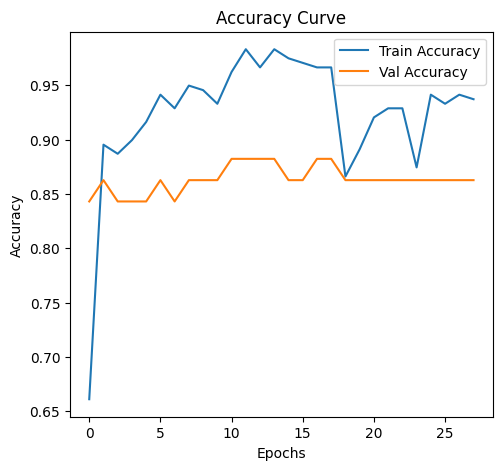

In [16]:
#By Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

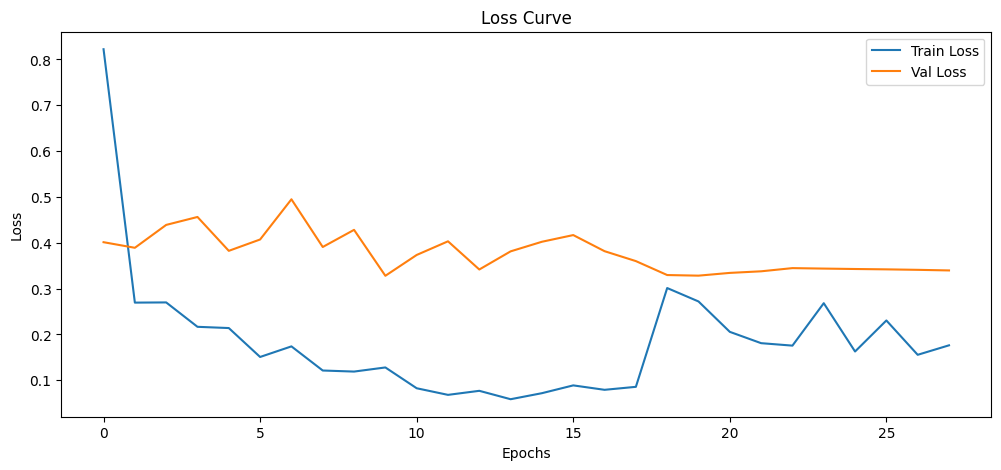

In [17]:
#By Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook

plt.figure(figsize=(12,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [18]:
# ============================================================
# FINAL EVALUATION ON UNSEEN TEST DATA
# ============================================================

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


2026-09-07 13:54:01.335813: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:54:01.471549: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Test Accuracy: 0.9038
Test Loss: 0.1654


In [19]:
# Predictions on unseen test data
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = y_pred_probs.argmax(axis=1)

# Compatibility aliases for visualization cells below
X_eval = X_test
y_eval = y_test


## Confusion Matrix

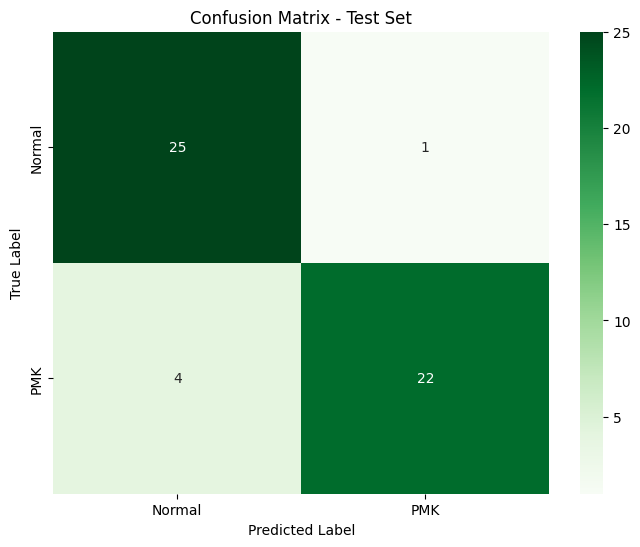

In [20]:
cm = confusion_matrix(y_test, y_pred)

display_names = [LABEL_NAMES[i] for i in range(len(CLASSES))]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=display_names,
    yticklabels=display_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()


## Classification Report

In [21]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[LABEL_NAMES[i] for i in range(len(CLASSES))]
    )
)


Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.96      0.91        26
         PMK       0.96      0.85      0.90        26

    accuracy                           0.90        52
   macro avg       0.91      0.90      0.90        52
weighted avg       0.91      0.90      0.90        52



## K-Fold Cross-Validation (Robustness Check)

The single 70/15/15 split above evaluates the model on only **52 test images**, so
one extra correct/incorrect prediction moves the accuracy by ~2%. That single
number can be lucky or unlucky depending on which images happened to land in
the test set.

To get a more reliable estimate of how well this approach generalizes on this
small dataset, we run **5-fold stratified cross-validation**: the full dataset
is split into 5 folds, and for each fold a fresh MobileNetV2 model is trained
(head-only, then fine-tuned) on the other 4 folds and evaluated on the held-out
fold. This does **not** replace the model already trained and exported above —
it's an independent robustness check on the same modeling approach.

This will take a few minutes since it trains 5 models end-to-end.


In [22]:
# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_accuracies = []
fold_reports = []

def build_fold_model():
    fb = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    fb.trainable = False

    finp = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    fx = Rescaling(255.0)(finp)
    fx = preprocess_input(fx)
    fx = fb(fx, training=False)
    fx = GlobalAveragePooling2D()(fx)
    fx = Dense(128, activation="relu")(fx)
    fx = Dropout(0.4)(fx)
    fout = Dense(2, activation="softmax")(fx)

    fm = keras.Model(finp, fout)
    return fm, fb

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n===== Fold {fold}/{N_FOLDS} =====")

    X_tr, X_va = X[train_idx], X[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]

    cw_values = compute_class_weight(
        class_weight="balanced", classes=np.unique(y_tr), y=y_tr
    )
    cw_dict = {i: w for i, w in enumerate(cw_values)}

    fold_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True
    )
    fold_datagen.fit(X_tr)

    fold_model, fold_base = build_fold_model()

    fold_callbacks = [
        EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
    ]

    # Phase 1: train head only
    fold_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    fold_model.fit(
        fold_datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True),
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        class_weight=cw_dict,
        callbacks=fold_callbacks,
        verbose=0
    )

    # Phase 2: fine-tune top layers of the backbone
    fold_base.trainable = True
    fine_tune_at = len(fold_base.layers) - 30
    for layer in fold_base.layers[:fine_tune_at]:
        layer.trainable = False

    fold_model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    fold_model.fit(
        fold_datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True),
        validation_data=(X_va, y_va),
        epochs=FINE_TUNE_EPOCHS,
        class_weight=cw_dict,
        callbacks=fold_callbacks,
        verbose=0
    )

    val_loss, val_acc = fold_model.evaluate(X_va, y_va, verbose=0)
    fold_pred = fold_model.predict(X_va, verbose=0).argmax(axis=1)

    report = classification_report(
        y_va, fold_pred,
        target_names=[LABEL_NAMES[i] for i in range(len(CLASSES))],
        output_dict=True,
        zero_division=0
    )

    fold_accuracies.append(val_acc)
    fold_reports.append(report)

    print(f"Fold {fold} accuracy: {val_acc:.4f} | loss: {val_loss:.4f}")

    # free GPU memory before the next fold
    del fold_model, fold_base
    keras.backend.clear_session()

print("\n===== K-Fold Cross-Validation Summary =====")
print("Accuracy per fold:", [f"{a:.4f}" for a in fold_accuracies])
print(f"Mean accuracy: {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")



===== Fold 1/5 =====


2026-09-07 13:54:30.200286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:54:30.333532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:54:44.956663: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:54:45.107404: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:54:45.243634: E external/local_xla/xla/stream_

Fold 1 accuracy: 0.9275 | loss: 0.1646

===== Fold 2/5 =====
Fold 2 accuracy: 0.9275 | loss: 0.1813

===== Fold 3/5 =====


2026-09-07 13:57:45.634854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:57:45.789140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:57:45.925672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:58:00.162751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:58:00.298507: E external/local_xla/xla/stream_

Fold 3 accuracy: 0.9118 | loss: 0.2297

===== Fold 4/5 =====
Fold 4 accuracy: 0.8676 | loss: 0.3358

===== Fold 5/5 =====
Fold 5 accuracy: 0.9118 | loss: 0.2459

===== K-Fold Cross-Validation Summary =====
Accuracy per fold: ['0.9275', '0.9275', '0.9118', '0.8676', '0.9118']
Mean accuracy: 0.9092 +/- 0.0220


### Cross-Validation Results by Class

Precision / recall / F1 for each class, averaged across all 5 folds, with the
standard deviation showing how much that metric varies fold to fold.


       precision              recall            f1-score          
            mean       std      mean       std      mean       std
class                                                             
Normal  0.881752  0.023823  0.947731  0.038548  0.913247  0.025259
PMK     0.943622  0.038123  0.869697  0.027117  0.904720  0.023942


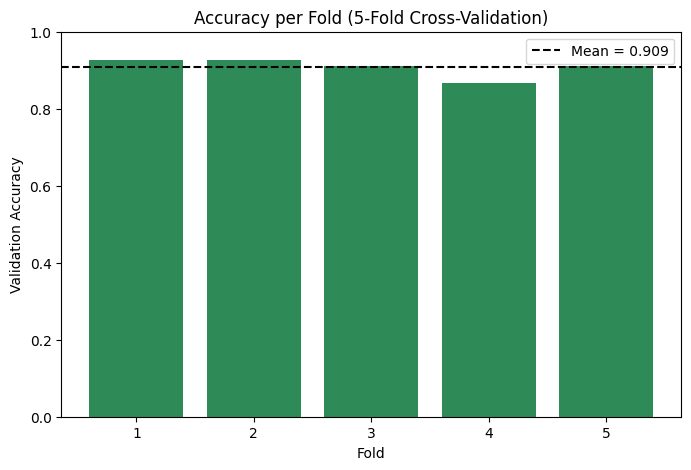

In [23]:
# ============================================================
# AGGREGATE PER-CLASS METRICS ACROSS FOLDS
# ============================================================

summary_rows = []
for i, report in enumerate(fold_reports, start=1):
    for label in LABEL_NAMES.values():
        summary_rows.append({
            "fold": i,
            "class": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"],
            "f1-score": report[label]["f1-score"]
        })

summary_df = pd.DataFrame(summary_rows)
agg = summary_df.groupby("class")[["precision", "recall", "f1-score"]].agg(["mean", "std"])
print(agg)

plt.figure(figsize=(8, 5))
plt.bar(range(1, N_FOLDS + 1), fold_accuracies, color="seagreen")
plt.axhline(np.mean(fold_accuracies), color="black", linestyle="--",
            label=f"Mean = {np.mean(fold_accuracies):.3f}")
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("Accuracy per Fold (5-Fold Cross-Validation)")
plt.xticks(range(1, N_FOLDS + 1))
plt.ylim(0, 1)
plt.legend()
plt.show()


### Predictions Removing the Blue (RGB channels)

 reverting the order of bgr matrix to rgb by reading the matrix from right to left:

**plt.imshow(X_val[i][:,:,::-1])**

answered Jan 8, 2022 at 18:48 by Salvatore Pannozzo Capodiferro

**np.flip(img, axis=-1)**  answered Mar 10, 2021 at 12:18 Alexander Mathiasen

https://stackoverflow.com/questions/39316447/opencv-giving-wrong-color-to-colored-images-on-loading

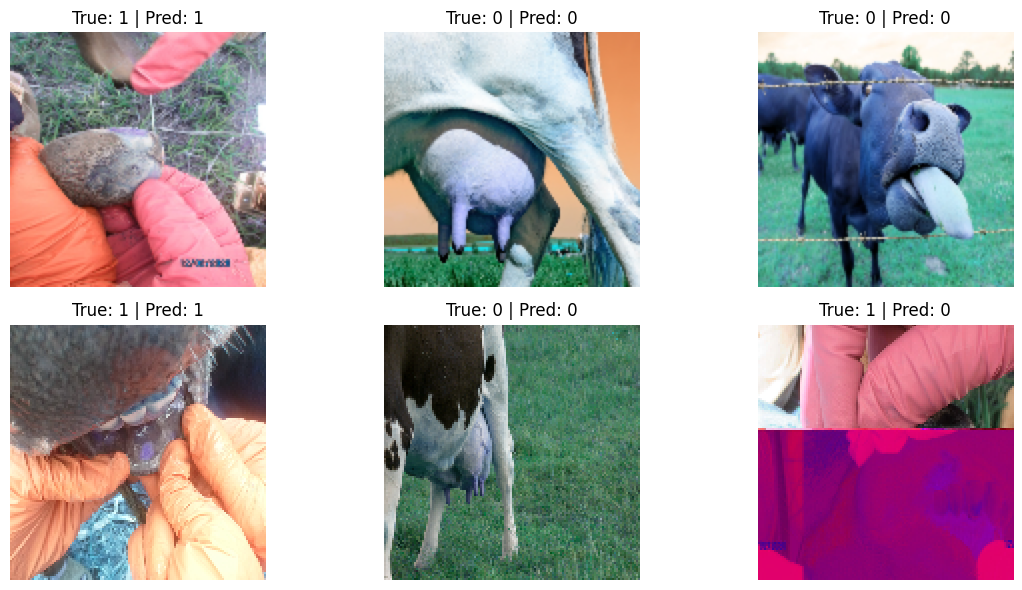

In [24]:
#By Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook

plt.figure(figsize=(12,6))

for i in range(min(6, len(X_eval))):
    plt.subplot(2,3,i+1)
    #plt.imshow(X_eval[i]) #Images were Blue
    #plt.imshow(cv2.cvtColor(X_eval[i], cv2.COLOR_BGR2RGB)) Didn't work
    plt.imshow(X_eval[i][:,:,::-1]) #That's reverted PERFECTLY the BRG to RGB
    plt.title(f"True: {y_eval[i]} | Pred: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Option  (np.flip(img, axis=-1))

https://stackoverflow.com/questions/39316447/opencv-giving-wrong-color-to-colored-images-on-loading

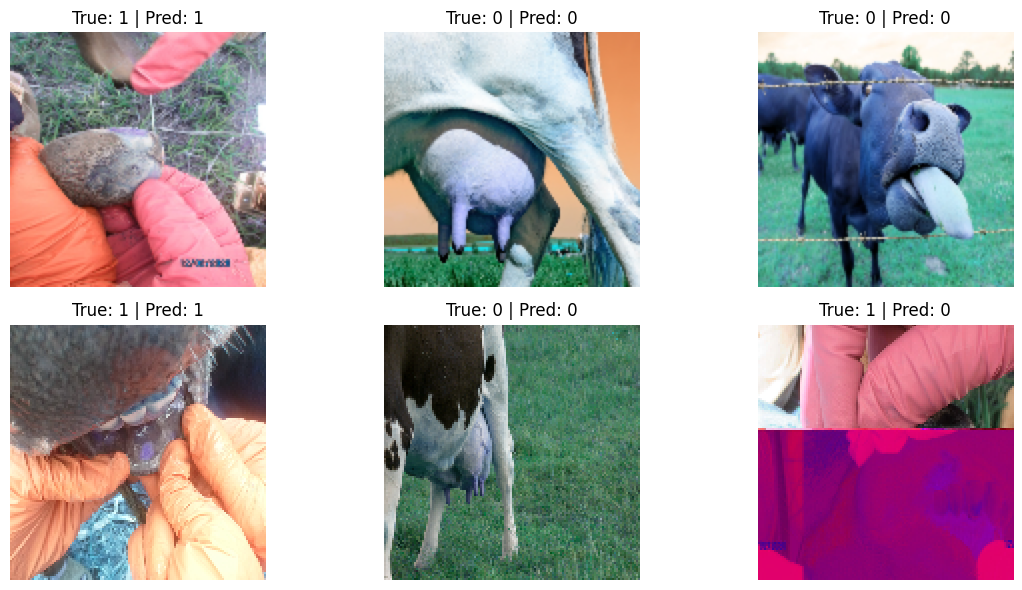

In [25]:
plt.figure(figsize=(12,6))

for i in range(min(6, len(X_eval))):
    plt.subplot(2,3,i+1)
    plt.imshow(np.flip(X_eval[i], axis=-1))
    #plt.imshow(cv2.cvtColor(X_eval[i], cv2.COLOR_BGR2RGB))#Resulted Error
    #plt.imshow(X_eval[i][:,:,::-1]) #OK
    plt.title(f"True: {y_eval[i]} | Pred: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Misclassified images

In [26]:
#By Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook

# BUG FIX: y_pred was computed from X_test (52 samples), but this
# cell was comparing it against y_val (51 samples) -> shape
# mismatch ValueError. Use y_eval/X_eval (aliases for the test
# set, defined right after the predictions were made) instead.
misclassified_idx = np.where(y_eval != y_pred)[0]

print("Number of misclassified samples:", len(misclassified_idx))


Number of misclassified samples: 5


## Misclassified images

How to take that Blue color of this images. 

[:,:,::-1]  Worked perfectly FINALLY!!


2nd Option  (np.flip(img, axis=-1))    x is Our image

x = cv2.imread('./image.jpg')

x=x[:,:,::-1]      (All rows, All columns, after reading the image, reverting the order of bgr matrix to rgb by reading the matrix from right to left)

OR: np.flip(img, axis=-1) 


https://stackoverflow.com/questions/39316447/opencv-giving-wrong-color-to-colored-images-on-loading


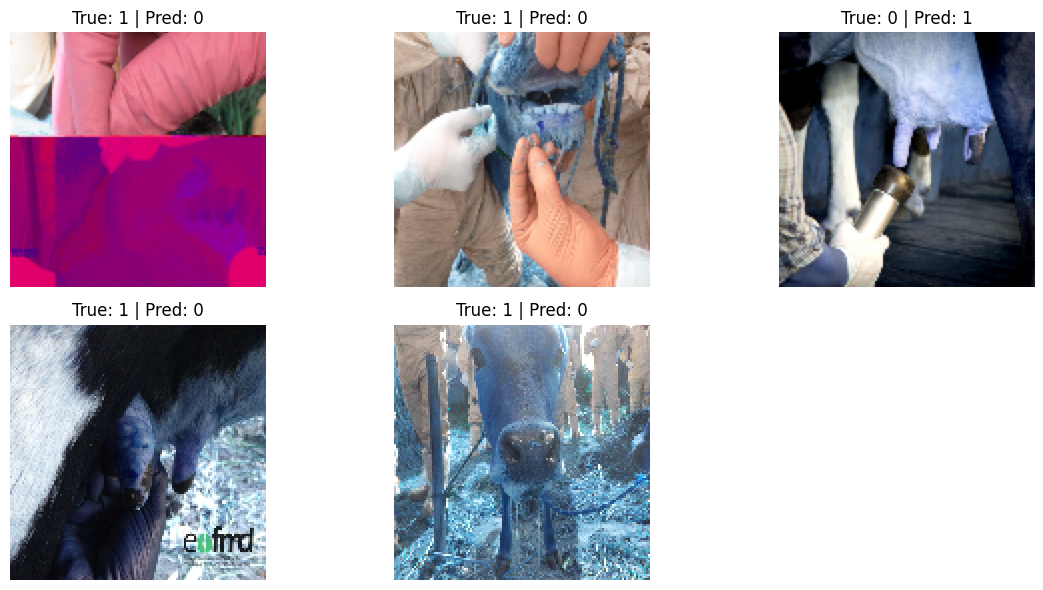

In [27]:
#By Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook

plt.figure(figsize=(12,6))

for i, idx in enumerate(misclassified_idx[:6]):
    plt.subplot(2,3,i+1)
    plt.imshow(X_eval[idx][:,:,::-1])
    plt.title(f"True: {y_eval[idx]} | Pred: {y_pred[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Draft Session: 2h:20min

Most of this time trying to change the Blue colors of this images and failing. But finally I got it.

Thanks to StackOverflow (OpenCV giving wrong color to colored images on loading)

https://stackoverflow.com/questions/39316447/opencv-giving-wrong-color-to-colored-images-on-loading

## Export Model for Raspberry Pi

After the model has been trained and evaluated, the following cells create the deployment files: `.keras`, `.tflite`, and `labels.txt`.

In [28]:
# ============================================================
# SAVE TRAINED KERAS MODEL
# ============================================================

KERAS_MODEL_PATH = "/kaggle/working/fmd_cattle_model.keras"

model.save(KERAS_MODEL_PATH)

print("Keras model saved:")
print(KERAS_MODEL_PATH)


Keras model saved:
/kaggle/working/fmd_cattle_model.keras


In [29]:
# ============================================================
# CONVERT TO TENSORFLOW LITE
# Raspberry Pi deployment format
# ============================================================

TFLITE_MODEL_PATH = "/kaggle/working/fmd_cattle_model.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Basic optimization for a smaller/faster model
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(TFLITE_MODEL_PATH, "wb") as f:
    f.write(tflite_model)

print("TFLite model saved:")
print(TFLITE_MODEL_PATH)
print(f"Model size: {os.path.getsize(TFLITE_MODEL_PATH) / (1024 * 1024):.2f} MB")


INFO:tensorflow:Assets written to: /tmp/tmph_2h0def/assets


INFO:tensorflow:Assets written to: /tmp/tmph_2h0def/assets


Saved artifact at '/tmp/tmph_2h0def'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137810220347280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220348624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220351312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220350928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220349776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220351120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220339600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220350736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220350544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137810220349968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1378102203

W0000 00:00:1788789712.051065      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1788789712.051107      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1788789712.196610      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [30]:
# ============================================================
# SAVE LABELS FOR RASPBERRY PI
# IMPORTANT: order must match model output indexes.
# ============================================================

LABELS_PATH = "/kaggle/working/labels.txt"

labels = [
    "Normal",
    "PMK"
]

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    for label in labels:
        f.write(label + "\n")

print("Labels saved:")
print(LABELS_PATH)

print("\nLabel mapping:")
for i, label in enumerate(labels):
    print(f"{i} = {label}")


Labels saved:
/kaggle/working/labels.txt

Label mapping:
0 = Normal
1 = PMK


## Verify TFLite Model

This checks that the exported `.tflite` model can be loaded and run successfully.

In [31]:
# ============================================================
# VERIFY TFLITE MODEL
# ============================================================

interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:")
print(input_details)

print("\nOutput details:")
print(output_details)

# Test inference using one unseen test image
sample = X_test[0:1].astype(np.float32)

interpreter.set_tensor(input_details[0]["index"], sample)
interpreter.invoke()

tflite_prediction = interpreter.get_tensor(output_details[0]["index"])
predicted_class = int(np.argmax(tflite_prediction[0]))

print("\nTFLite test prediction:", tflite_prediction[0])
print("Predicted class:", predicted_class, "-", LABEL_NAMES[predicted_class])
print("Actual class   :", int(y_test[0]), "-", LABEL_NAMES[int(y_test[0])])


Input details:
[{'name': 'serving_default_keras_tensor_154:0', 'index': 0, 'shape': array([  1, 128, 128,   3], dtype=int32), 'shape_signature': array([ -1, 128, 128,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output details:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 181, 'shape': array([1, 2], dtype=int32), 'shape_signature': array([-1,  2], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

TFLite test prediction: [0.44891307 0.55108684]
Predicted class: 1 - PMK
Actual class   : 1 - PMK


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Final Deployment Files

Download these files from Kaggle's Output section after running the notebook successfully:

- `fmd_cattle_model.tflite` → Raspberry Pi inference
- `labels.txt` → class mapping
- `fmd_cattle_model.keras` → backup / future retraining
- `best_fmd_cattle_model.keras` → best validation checkpoint

In [32]:
# ============================================================
# SHOW FINAL FILES
# ============================================================

print("Files ready in /kaggle/working:\n")

for filename in sorted(os.listdir("/kaggle/working")):
    filepath = os.path.join("/kaggle/working", filename)
    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"{filename:40s} {size_mb:.2f} MB")


Files ready in /kaggle/working:

__notebook__.ipynb                       2.81 MB
best_fmd_cattle_model.keras              11.06 MB
fmd_cattle_model.keras                   22.73 MB
fmd_cattle_model.tflite                  2.55 MB
labels.txt                               0.00 MB


## Raspberry Pi Inference Reference

The Raspberry Pi must use the same preprocessing as training: **BGR → RGB, resize to 128×128, convert to float32, divide by 255.0, then add batch dimension**.

In [33]:
# Example Raspberry Pi preprocessing logic
# This is a reference cell; run it on the Raspberry Pi after
# copying fmd_cattle_model.tflite and labels.txt.

# frame_bgr = ...  # frame from camera
# img = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
# img = cv2.resize(img, (128, 128))
# img = img.astype(np.float32) / 255.0
# img = np.expand_dims(img, axis=0)
#
# interpreter.set_tensor(input_details[0]["index"], img)
# interpreter.invoke()
# prediction = interpreter.get_tensor(output_details[0]["index"])[0]
# predicted_index = int(np.argmax(prediction))
#
# labels = ["Normal", "PMK"]
# print(labels[predicted_index], float(prediction[predicted_index]))


In [34]:
#Acknowledgements:

#Amir Charkhi Matplotlib Tutorial - Part 12: Show Images Using IMSHOW 
#https://www.youtube.com/watch?v=1eYfoCtMmPY

#Bisma Ali https://www.kaggle.com/code/bismahali/karachi-transport-dataset-eda-ida

#Piyush Joshi https://www.kaggle.com/code/piyushjoshi01/0-5-fingers-cnn-model/notebook